In [3]:
#pip install pandas xarray numba

In [4]:
#conda  install xarray

In [1]:
import os
import json
import time
import xarray as xr
import numpy as np
import colorcet as cc

from moistconvUtil import (
    create_masked_colormap,
    hex_to_rgb,
    rgb_to_dec,
    get_continuous_cmap,
    LSMCPlotter,
    LSMCPlotterROW2
)

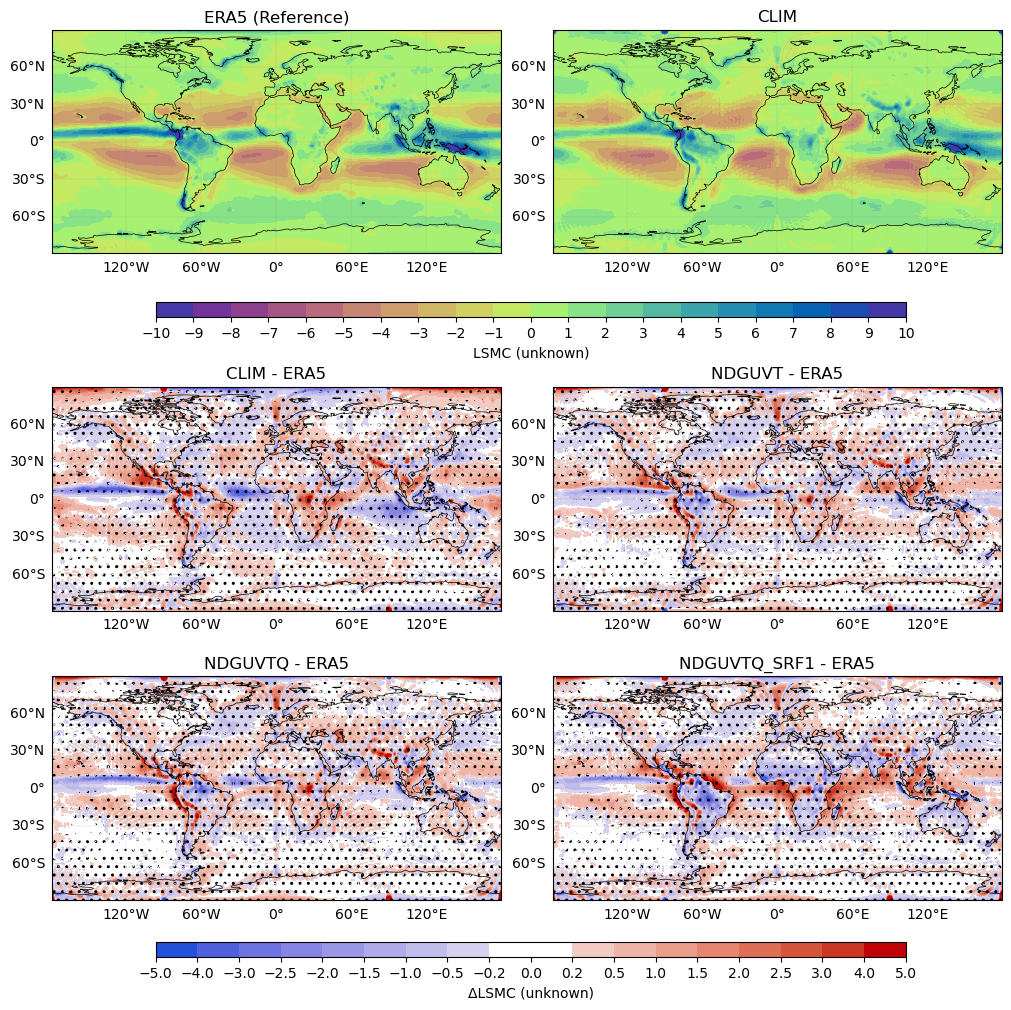

[PLOT] 3-row comparison saved: ./Figure_C3.pdf


In [2]:
if __name__ == "__main__":
    # === Basic Paths ===
    top_path  = "/anvil/scratch/x-szhang3"
    data_path = f"{top_path}/post_data"
    out_path  = f"/home/x-szhang3/nudging_analysis/nudging_evaluation/data/lsmc_diagnostics"
    fig_path  = "./"
    os.makedirs(fig_path, exist_ok=True)

    # === Load Experiment Metadata (and alias mapping) ===
    exp_dict = {
        "CLIM"         : "CLIM",
        # "NDGUV"        : "NDG-UV",
        "NDGUVT"       : "NDG-UVT",
        "NDGUVTQ"      : "NDG-UVTQ",
        "NDGUVTQ_SRF1" : "NDG-UVTQ_SRF1"
    }

    ref_model = "ERA5"
    model_names = list(exp_dict.keys())
    years = range(2008, 2018)
    #seasons = ["ANN", "DJF", "MAM", "JJA", "SON"]
    seasons = ["ANN"]
    
    # === Colormap Settings ===
    dif_cmap = cc.cm["CET_CBTD1"]  # diverging colormap for differences
    raw_cmap = cc.cm["CET_D1A"] # sequential for raw values

    raw_cmap = cc.cm["CET_C9s"] # sequential for raw values
    dif_cmap = cc.cm["CET_D1"]  # diverging colormap for differences

    # === Levels ===
    raw_clevels = np.linspace(-10, 10, 21)  # Raw LSMC values
    diff_clevels = [ -5, -4, -3, -2.5, -2, -1.5, -1, -0.5, -0.2, 0.0, 0.2, 0.5, 1, 1.5, 2, 2.5, 3, 4, 5]  # Differences

    # === Create Plotter Instance ===
    plotter = LSMCPlotter(
        model_names=model_names,
        ref_model=ref_model,
        data_path=out_path,
        varname="LSMC",
        dif_cmap=dif_cmap,
        clevels=diff_clevels,
        raw_cmap=raw_cmap,
        raw_clevels=raw_clevels,
        sig_level=0.05,
        smooth_sigma=1.0
    )

    # === Loop Through Seasons ===
    for season in seasons:
        fig_name = "Figure_C3.pdf"
        try:
            plotter.plot_multi_model_comparison(
                season=season,
                years=years,
                save_path=fig_path,
                fig_name=fig_name
            )
        except Exception as e:
            print(f"[ERROR] Failed to plot multi-model comparison for {season}: {e}")
